# Solution : Régression avec MLP

Prédiction de prix d'immobilier avec un réseau de neurones.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, layers, optimizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Tâche 1 : Chargement et Exploration

In [6]:

# Fallback si Boston Housing est dépréciée
data = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')
X = data.drop('medv', axis=1).values
y = data['medv'].values

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures: {feature_names}")
print(f"\nTarget (price) range: [{y.min():.1f}, {y.max():.1f}]")

X shape: (506, 13)
y shape: (506,)

Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Target (price) range: [5.0, 50.0]


In [7]:
# Exploration
df = pd.DataFrame(X, columns=feature_names)
df['price'] = y

print("Statistiques descriptives:")
print(df.describe())

# Corrélations
corr = df.corr()['price'].sort_values(ascending=False)
print("\nCorréactions avec le prix:")
print(corr)

Statistiques descriptives:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   


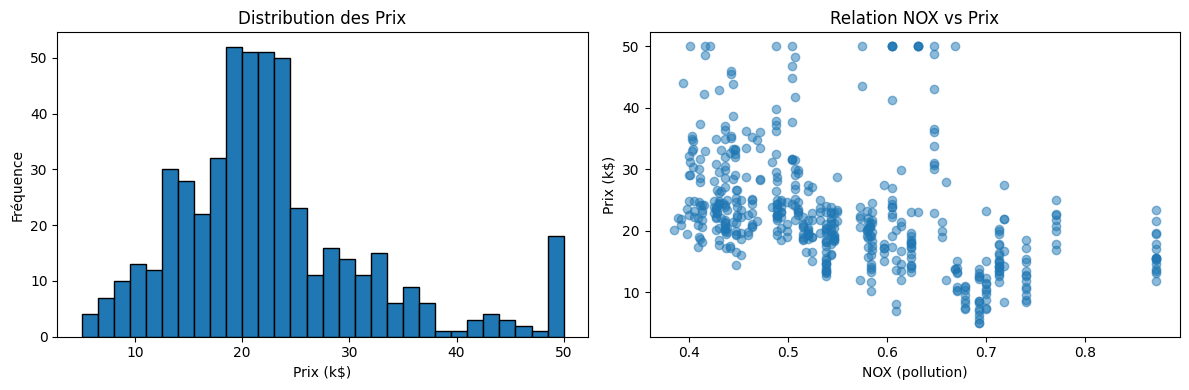

In [8]:
# Distribution du prix
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=30, edgecolor='black')
plt.xlabel('Prix (k$)')
plt.ylabel('Fréquence')
plt.title('Distribution des Prix')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 4], y, alpha=0.5)  # NOX vs price
plt.xlabel('NOX (pollution)')
plt.ylabel('Prix (k$)')
plt.title('Relation NOX vs Prix')

plt.tight_layout()
plt.show()

## Tâche 2 : Préparation

In [ ]:
# Normaliser
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# Split
X_temp, X_test, y_temp, y_test = train_test_split(X_norm, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1756, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (323, 13)
Val: (81, 13)
Test: (102, 13)


## Tâche 3-4 : Architecture et Entraînement

In [ ]:
model = Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1) 
])

model.compile(
    optimizer="adam",
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Entraîner
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 583.3490 - mae: 22.2496 - val_loss: 538.5263 - val_mae: 21.6631
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 510.6902 - mae: 20.6482 - val_loss: 433.6330 - val_mae: 19.2591
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 346.7008 - mae: 16.4801 - val_loss: 211.7386 - val_mae: 13.1687
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 118.7342 - mae: 8.9350 - val_loss: 66.2422 - val_mae: 6.2762
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 52.1135 - mae: 5.7508 - val_loss: 47.6832 - val_mae: 5.0835
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 35.5294 - mae: 4.4666 - val_loss: 40.3139 - val_mae: 4.5718
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26.7180 - mae: 3.7921 - val_loss: 37.4291 - val_mae: 4.3158
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.7806 - mae: 3.5233 - val_loss: 34.0224 - val_mae: 4.1335
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R²: {r2:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Test MSE: 11.9348
Test RMSE: 3.4547
Test MAE: 2.1711
Test R²: 0.8373


## Tâche 5 : Analyse des Prédictions

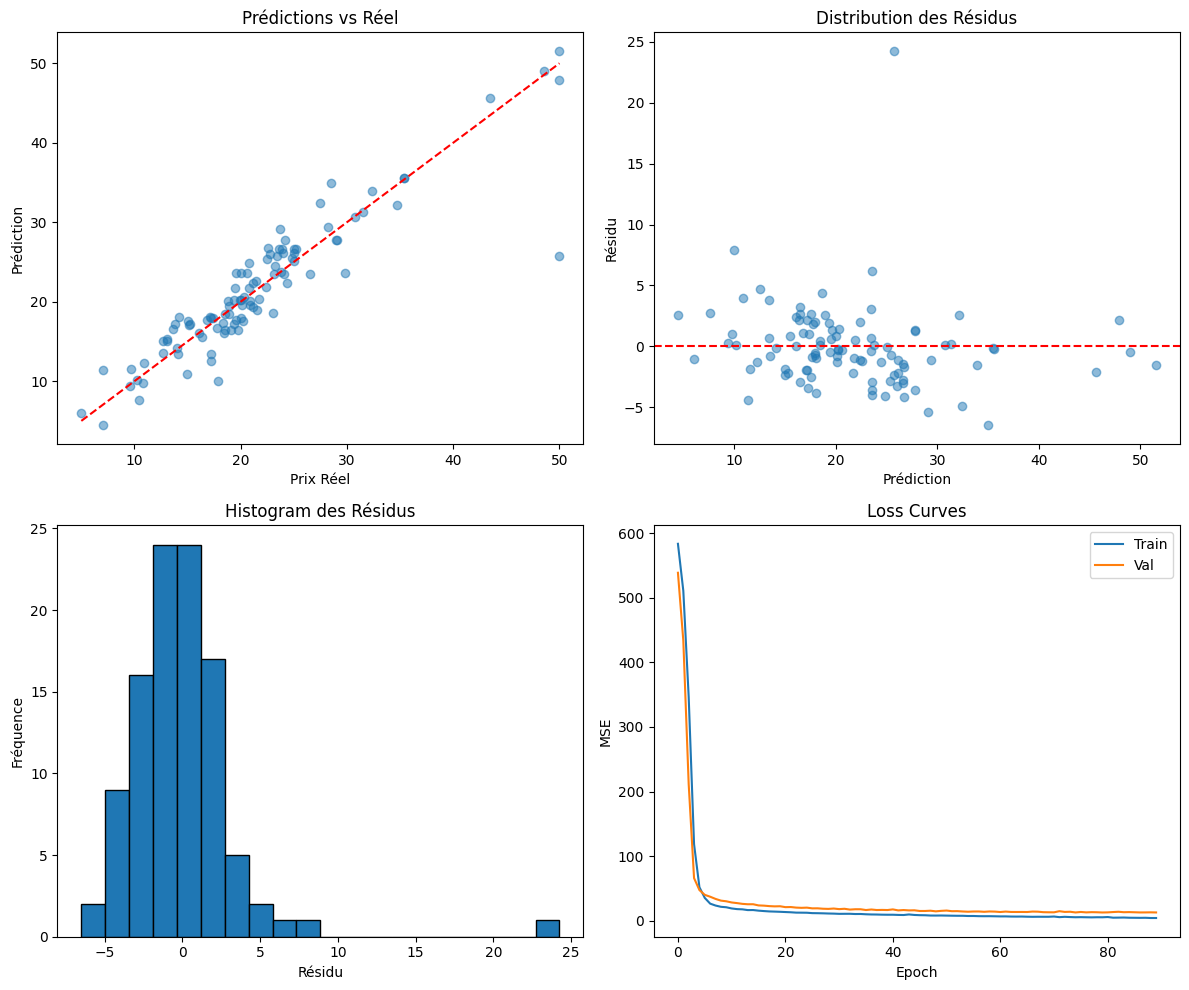

In [13]:
# Residuals
residuals = y_test - y_pred.flatten()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Prédictions vs Réel
axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0, 0].set_xlabel('Prix Réel')
axes[0, 0].set_ylabel('Prédiction')
axes[0, 0].set_title('Prédictions vs Réel')

# Residuals
axes[0, 1].scatter(y_pred, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Prédiction')
axes[0, 1].set_ylabel('Résidu')
axes[0, 1].set_title('Distribution des Résidus')

# Histogram residuals
axes[1, 0].hist(residuals, bins=20, edgecolor='black')
axes[1, 0].set_xlabel('Résidu')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Histogram des Résidus')

# Training curves
axes[1, 1].plot(history.history['loss'], label='Train')
axes[1, 1].plot(history.history['val_loss'], label='Val')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MSE')
axes[1, 1].set_title('Loss Curves')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [14]:
# Erreurs par plage de prix
price_ranges = [0, 10, 20, 30, 40, 50]
for i in range(len(price_ranges)-1):
    mask = (y_test >= price_ranges[i]) & (y_test < price_ranges[i+1])
    if mask.sum() > 0:
        mae_range = mean_absolute_error(y_test[mask], y_pred[mask])
        print(f"Plage ${price_ranges[i]}-${price_ranges[i+1]}k: MAE={mae_range:.2f}k$")

Plage $0-$10k: MAE=2.03k$
Plage $10-$20k: MAE=1.91k$
Plage $20-$30k: MAE=2.18k$
Plage $30-$40k: MAE=0.78k$
Plage $40-$50k: MAE=1.28k$


## Tâche 6 : Amélioration

In [15]:
# Modèle amélioré avec régularisation
model_improved = Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu', kernel_regularizer='l2'),
    layers.Dense(1)
])

model_improved.compile(
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

history_improved = model_improved.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

y_pred_improved = model_improved.predict(X_test, verbose=0)
r2_improved = r2_score(y_test, y_pred_improved)

print(f"\nComparaison:")
print(f"Modèle Original R²: {r2:.4f}")
print(f"Modèle Amélioré R²: {r2_improved:.4f}")
print(f"Gain: {(r2_improved - r2):.4f}")


Comparaison:
Modèle Original R²: 0.8373
Modèle Amélioré R²: -5.7898
Gain: -6.6271


### Bonus 1 : Loss Function Personnalisée

Créons une loss function qui pénalise davantage les sous-estimations (car vendre trop bas est plus problématique).

In [16]:
@tf.function
def asymmetric_mse(y_true, y_pred):
    """
    Loss personnalisée qui pénalise davantage les sous-estimations.
    - Si prédiction < réel (sous-estimation) : pénalité x2
    - Si prédiction > réel (sur-estimation) : pénalité normale
    """
    error = y_true - y_pred
    
    # Masque pour sous-estimations (error > 0 signifie qu'on a prédit trop bas)
    underestimate = tf.cast(error > 0, tf.float32)
    
    # Pénalité asymétrique
    penalty = tf.where(error > 0, 
                       2.0 * tf.square(error),  # Sous-estimation : pénalité x2
                       tf.square(error))         # Sur-estimation : pénalité normale
    
    return tf.reduce_mean(penalty)


model_custom_loss = Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model_custom_loss.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=asymmetric_mse,
    metrics=['mae']
)


history_custom = model_custom_loss.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

y_pred_custom = model_custom_loss.predict(X_test, verbose=0)

underestimates_mse = np.mean((y_test[y_pred_custom.flatten() < y_test] - y_pred_custom.flatten()[y_pred_custom.flatten() < y_test])**2)
overestimates_mse = np.mean((y_test[y_pred_custom.flatten() > y_test] - y_pred_custom.flatten()[y_pred_custom.flatten() > y_test])**2)

print(f"Résultats avec Loss Asymétrique:")
print(f"   - Sous-estimations MSE: {underestimates_mse:.4f}")
print(f"   - Sur-estimations MSE: {overestimates_mse:.4f}")
print(f"   - R² global: {r2_score(y_test, y_pred_custom):.4f}")

underestimates_mse_base = np.mean((y_test[y_pred.flatten() < y_test] - y_pred.flatten()[y_pred.flatten() < y_test])**2)

print(f"\nComparaison avec modèle de base:")
print(f"   - Sous-estimations MSE (base): {underestimates_mse_base:.4f}")
print(f"   - Sous-estimations MSE (custom): {underestimates_mse:.4f}")
print(f"   - Amélioration: {((underestimates_mse_base - underestimates_mse) / underestimates_mse_base * 100):.1f}%")

Résultats avec Loss Asymétrique:
   - Sous-estimations MSE: 459.2479
   - Sur-estimations MSE: nan
   - R² global: -5.2624

Comparaison avec modèle de base:
   - Sous-estimations MSE (base): 19.7471
   - Sous-estimations MSE (custom): 459.2479
   - Amélioration: -2225.6%


### Bonus 2 : Huber Loss pour Robustesse

Huber Loss combine MSE et MAE : elle est quadratique pour petites erreurs et linéaire pour grandes erreurs.
Cela la rend **robuste aux outliers** !

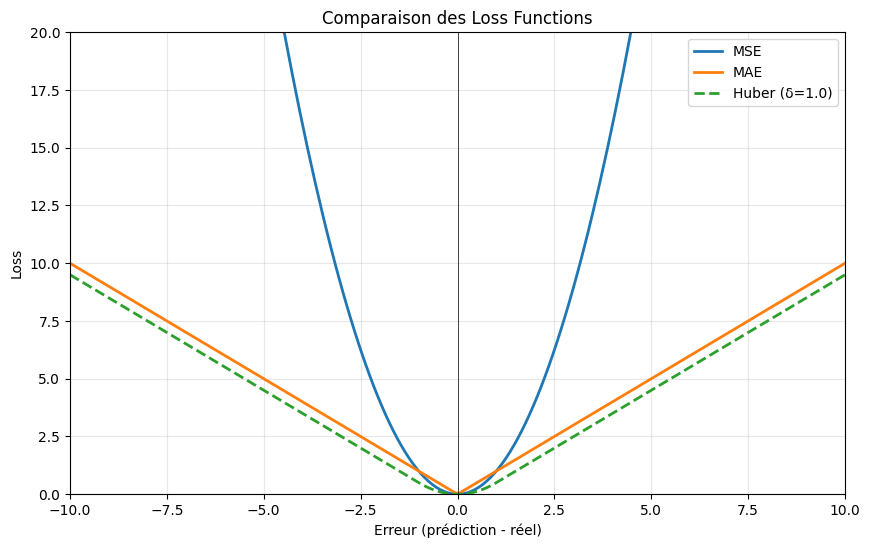

In [17]:
from tensorflow.keras.losses import Huber

# Visualiser la différence entre MSE, MAE et Huber
errors = np.linspace(-10, 10, 200)

mse_loss = errors ** 2
mae_loss = np.abs(errors)
huber_loss_values = []

# Huber avec delta=1.0
delta = 1.0
for e in errors:
    if np.abs(e) <= delta:
        huber_loss_values.append(0.5 * e**2)
    else:
        huber_loss_values.append(delta * (np.abs(e) - 0.5 * delta))

plt.figure(figsize=(10, 6))
plt.plot(errors, mse_loss, label='MSE', linewidth=2)
plt.plot(errors, mae_loss, label='MAE', linewidth=2)
plt.plot(errors, huber_loss_values, label='Huber (δ=1.0)', linewidth=2, linestyle='--')
plt.xlabel('Erreur (prédiction - réel)')
plt.ylabel('Loss')
plt.title('Comparaison des Loss Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-10, 10)
plt.ylim(0, 20)
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.show()

In [ ]:
# Modèle avec Huber Loss
model_huber = Sequential([
    layers.Input(shape=(13,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model_huber.compile(
    optimizer="adam",
    loss=Huber(delta=1.0), 
    metrics=['mae']
)

history_huber = model_huber.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

y_pred_huber = model_huber.predict(X_test, verbose=0)
r2_huber = r2_score(y_test, y_pred_huber)
mae_huber = mean_absolute_error(y_test, y_pred_huber)

print(f"Résultats avec Huber Loss:")
print(f"   - R²: {r2_huber:.4f}")
print(f"   - MAE: {mae_huber:.4f}")

# Comparaison avec MSE
print(f"\nComparaison:")
print(f"   - MSE Loss R²: {r2:.4f}")
print(f"   - Huber Loss R²: {r2_huber:.4f}")
print(f"   - Différence: {(r2_huber - r2):.4f}")

# Analyser la robustesse aux outliers
residuals_mse = np.abs(y_test - y_pred.flatten())
residuals_huber = np.abs(y_test - y_pred_huber.flatten())

# Identifier les outliers (résidus > 10k$)
outliers_mask = residuals_mse > 10

print(f"\nRobustesse aux outliers (erreurs > 10k$):")
print(f"   - Nombre d'outliers: {outliers_mask.sum()}")
print(f"   - Erreur moyenne MSE sur outliers: {residuals_mse[outliers_mask].mean():.2f}k$")
print(f"   - Erreur moyenne Huber sur outliers: {residuals_huber[outliers_mask].mean():.2f}k$")

Résultats avec Huber Loss:
   - R²: 0.8508
   - MAE: 2.1431

Comparaison:
   - MSE Loss R²: 0.8373
   - Huber Loss R²: 0.8508
   - Différence: 0.0136

🎯 Robustesse aux outliers (erreurs > 10k$):
   - Nombre d'outliers: 1
   - Erreur moyenne MSE sur outliers: 24.26k$
   - Erreur moyenne Huber sur outliers: 21.76k$


### Bonus 3 : Ensemble Methods (Moyenne de Modèles)

L'idée : entraîner **plusieurs modèles différents** et faire la **moyenne de leurs prédictions**.
Cela réduit la variance et améliore la robustesse !

In [ ]:
def create_model(hidden_units, learning_rate=0.001, seed=None):
    if seed is not None:
        tf.random.set_seed(seed)
    
    model = Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(hidden_units[2], activation='relu'),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

ensemble_configs = [
    {'hidden_units': [64, 32, 16], 'lr': 0.001, 'seed': 42},
    {'hidden_units': [128, 64, 32], 'lr': 0.0005, 'seed': 123},
    {'hidden_units': [32, 32, 16], 'lr': 0.002, 'seed': 456},
    {'hidden_units': [64, 64, 32], 'lr': 0.001, 'seed': 789},
    {'hidden_units': [96, 48, 24], 'lr': 0.0008, 'seed': 999}
]

ensemble_models = []
ensemble_predictions = []

for i, config in enumerate(ensemble_configs):
    print(f"Entraînement du modèle {i+1}/5 : {config['hidden_units']} (lr={config['lr']})")
    
    model = create_model(
        hidden_units=config['hidden_units'],
        learning_rate=config['lr'],
        seed=config['seed']
    )
    
    history_ens = model.fit(
        X_train, y_train,
        batch_size=16,
        epochs=100,
        validation_data=(X_val, y_val),
        callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    
 
    y_pred_ens = model.predict(X_test, verbose=0)
  
    ensemble_models.append(model)
    ensemble_predictions.append(y_pred_ens.flatten())

    r2_ens = r2_score(y_test, y_pred_ens)
    print(f"R² individuel: {r2_ens:.4f}\n")


Entraînement du modèle 1/5 : [64, 32, 16] (lr=0.001)
R² individuel: 0.8175

Entraînement du modèle 2/5 : [128, 64, 32] (lr=0.0005)
R² individuel: 0.8247

Entraînement du modèle 3/5 : [32, 32, 16] (lr=0.002)
R² individuel: 0.8093

Entraînement du modèle 4/5 : [64, 64, 32] (lr=0.001)
R² individuel: 0.8323

Entraînement du modèle 5/5 : [96, 48, 24] (lr=0.0008)
R² individuel: 0.8295



In [20]:

y_pred_ensemble = np.mean(ensemble_predictions, axis=0)

r2_ensemble = r2_score(y_test, y_pred_ensemble)
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))

print("Performance de l'Ensemble (moyenne de 5 modèles):")
print(f"   - R²: {r2_ensemble:.4f}")
print(f"   - MAE: {mae_ensemble:.4f}")
print(f"   - RMSE: {rmse_ensemble:.4f}")

# Performances individuelles pour comparaison
r2_individuals = [r2_score(y_test, pred) for pred in ensemble_predictions]
print(f"\nComparaison:")
print(f"   - Meilleur modèle individuel R²: {max(r2_individuals):.4f}")
print(f"   - Pire modèle individuel R²: {min(r2_individuals):.4f}")
print(f"   - Moyenne modèles individuels R²: {np.mean(r2_individuals):.4f}")
print(f"   - Ensemble R²: {r2_ensemble:.4f}")
print(f"\n   Gain vs meilleur individuel: {(r2_ensemble - max(r2_individuals)):.4f}")

Performance de l'Ensemble (moyenne de 5 modèles):
   - R²: 0.8294
   - MAE: 2.2570
   - RMSE: 3.5366

Comparaison:
   - Meilleur modèle individuel R²: 0.8323
   - Pire modèle individuel R²: 0.8093
   - Moyenne modèles individuels R²: 0.8226
   - Ensemble R²: 0.8294

   Gain vs meilleur individuel: -0.0028


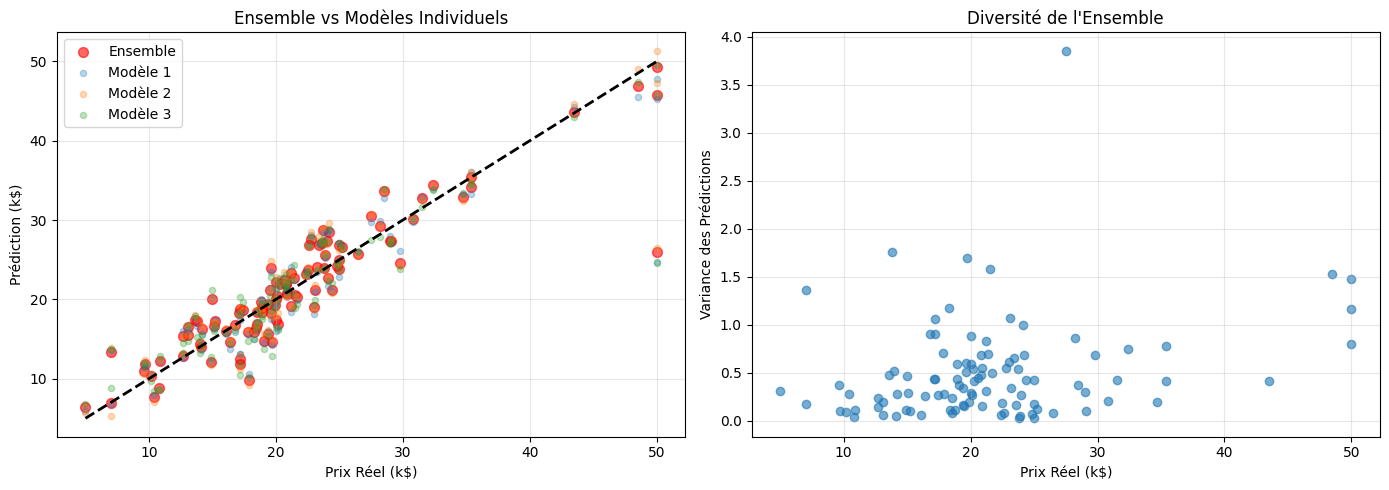

Analyse de la diversité:
   - Variance moyenne des prédictions: 0.4985
   - Variance max: 3.8548
   - Variance min: 0.0263


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Prédictions de chaque modèle vs Réel
axes[0].scatter(y_test, y_pred_ensemble, alpha=0.6, label='Ensemble', s=50, color='red')
for i, pred in enumerate(ensemble_predictions[:3]):  # Afficher 3 modèles individuels
    axes[0].scatter(y_test, pred, alpha=0.3, label=f'Modèle {i+1}', s=20)

axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=2)
axes[0].set_xlabel('Prix Réel (k$)')
axes[0].set_ylabel('Prédiction (k$)')
axes[0].set_title('Ensemble vs Modèles Individuels')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Variance des prédictions
prediction_variance = np.var(ensemble_predictions, axis=0)
axes[1].scatter(y_test, prediction_variance, alpha=0.6)
axes[1].set_xlabel('Prix Réel (k$)')
axes[1].set_ylabel('Variance des Prédictions')
axes[1].set_title('Diversité de l\'Ensemble')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analyse de la diversité:")
print(f"   - Variance moyenne des prédictions: {prediction_variance.mean():.4f}")
print(f"   - Variance max: {prediction_variance.max():.4f}")
print(f"   - Variance min: {prediction_variance.min():.4f}")